## Install dependencies

In [1]:
%%capture

!pip install -U unsloth
!pip install --no-deps transformers==5.5.0 "tokenizers>=0.22.0,<=0.23.0"
!pip install --no-deps --upgrade timm
!pip install -U datasets huggingface_hub accelerate bitsandbytes trl peft

## Imports and configurations

In [2]:
import os
import re
import gc
import json
import math
import random
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from datasets import load_dataset

SEED = 3407

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --------------------------------------------------------
# Experiment configuration
# --------------------------------------------------------

MODEL_NAME = "unsloth/gemma-4-E2B-it"

# Start with 8K for a Kaggle experiment.
# Change to 28299 later if you want the complete training set.
TRAIN_SAMPLES = 8_000

# Evaluate the same test examples before and after training.
# 500 is a reasonable notebook compromise.
EVAL_SAMPLES = 200

OUTPUT_DIR = "/kaggle/working/gemma4-e2b-chartqa"
LORA_DIR = "/kaggle/working/gemma4-e2b-chartqa-lora"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB",
    )

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


## Optional HuggingFace login

In [3]:
from huggingface_hub import login

try:
    from kaggle_secrets import UserSecretsClient

    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HUGGINGFACE_TOKEN")
    login(token=hf_token)
    print("Logged in to Hugging Face.")
except Exception as e:
    print("Hugging Face login skipped.")
    print("Reason:", e)

Logged in to Hugging Face.


## Load Gemma4:E2B

In [4]:
from unsloth import FastVisionModel

model, processor = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

print("Model loaded.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.18: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma4 won't work! Using float32.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/constants.py:310: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

Model loaded.


## Apply Gemma4 chat template

In [5]:
from unsloth import get_chat_template

processor = get_chat_template(
    processor,
    "gemma-4",
)

print("Gemma 4 chat template loaded.")

Gemma 4 chat template loaded.


## Load ChartQA

In [6]:
dataset = load_dataset("HuggingFaceM4/ChartQA")

dataset

README.md:   0%|          | 0.00/852 [00:00<?, ?B/s]

data/train-00000-of-00003-49492f364babfa(…): reconstructing file:   0%|          |  0.00B /  219MB            

data/train-00000-of-00003-49492f364babfa(…): downloading bytes:           |  0.00B            

data/train-00001-of-00003-7302bae5e425bb(…): reconstructing file:   0%|          |  0.00B /  311MB            

data/train-00001-of-00003-7302bae5e425bb(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-e2cd0b7a0f9eb20(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/28299 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1920 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 28299
    })
    val: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 1920
    })
    test: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 2500
    })
})

## Inspect one sample

Question:
Is the value of Favorable 38 in 2015?

Answer:
['Yes']

Human or machine:
0


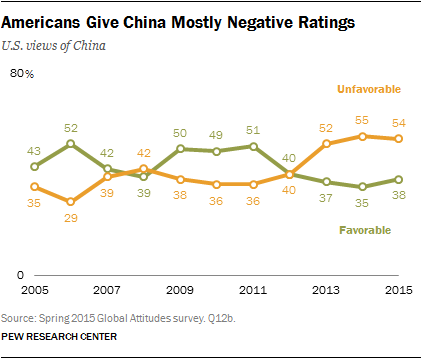

In [7]:
sample = dataset["train"][0]

print("Question:")
print(sample["query"])

print("\nAnswer:")
print(sample["label"])

print("\nHuman or machine:")
print(sample["human_or_machine"])

display(sample["image"])

## Define the task instruction

In [8]:
SYSTEM_INSTRUCTION = """
Answer the question using only the information visible in the chart.
Give only the final answer, without explanation.
Do not invent information that is not present in the chart.
""".strip()

## Build the prompt

In [9]:
def make_prompt(question):
    return f"""You are analyzing a chart.

{SYSTEM_INSTRUCTION}

Question: {question}"""

In [10]:
print(make_prompt(dataset["train"][0]["query"]))

You are analyzing a chart.

Answer the question using only the information visible in the chart.
Give only the final answer, without explanation.
Do not invent information that is not present in the chart.

Question: Is the value of Favorable 38 in 2015?


# Prepare the training dataset

In [11]:
train_raw = (
    dataset["train"]
    .shuffle(seed=SEED)
    .select(range(min(TRAIN_SAMPLES, len(dataset["train"]))))
)

print("Training samples:", len(train_raw))

Training samples: 8000


## Prepare a fixed test subset

In [12]:
test_raw = (
    dataset["test"]
    .shuffle(seed=SEED)
    .select(range(min(EVAL_SAMPLES, len(dataset["test"]))))
)

print("Evaluation samples:", len(test_raw))

Evaluation samples: 200


## Conversion function for Unsloth vision SFT

In [13]:
def convert_to_conversation(sample):
    image = sample["image"].convert("RGB")
    question = make_prompt(sample["query"])
    answer = str(sample["label"][0])

    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image,
                    },
                    {
                        "type": "text",
                        "text": question,
                    },
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {
                        "type": "text",
                        "text": answer,
                    },
                ],
            },
        ]
    }

## Convert training dataset

In [14]:
converted_train_dataset = [
    convert_to_conversation(sample)
    for sample in tqdm(train_raw, desc="Converting training data")
]

print("Converted samples:", len(converted_train_dataset))

Converting training data:   0%|          | 0/8000 [00:00<?, ?it/s]

Converted samples: 8000


In [15]:
from datasets import Dataset

converted_train_dataset = Dataset.from_list(
    converted_train_dataset
)

print(type(converted_train_dataset))
print(converted_train_dataset)

<class 'datasets.arrow_dataset.Dataset'>
Dataset({
    features: ['messages'],
    num_rows: 8000
})


## Define inference function

In [16]:
def generate_answer(
    image,
    question,
    model,
    processor,
    max_new_tokens=32,
):
    image = image.convert("RGB")

    prompt = make_prompt(question)

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                },
                {
                    "type": "text",
                    "text": prompt,
                },
            ],
        }
    ]

    input_text = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
    )

    inputs = processor(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    input_length = inputs["input_ids"].shape[1]

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True,
        )

    # Decode ONLY newly generated tokens, not the input prompt.
    generated_tokens = outputs[:, input_length:]

    answer = processor.batch_decode(
        generated_tokens,
        skip_special_tokens=True,
    )[0]

    return answer.strip()

## Test base model on one chart

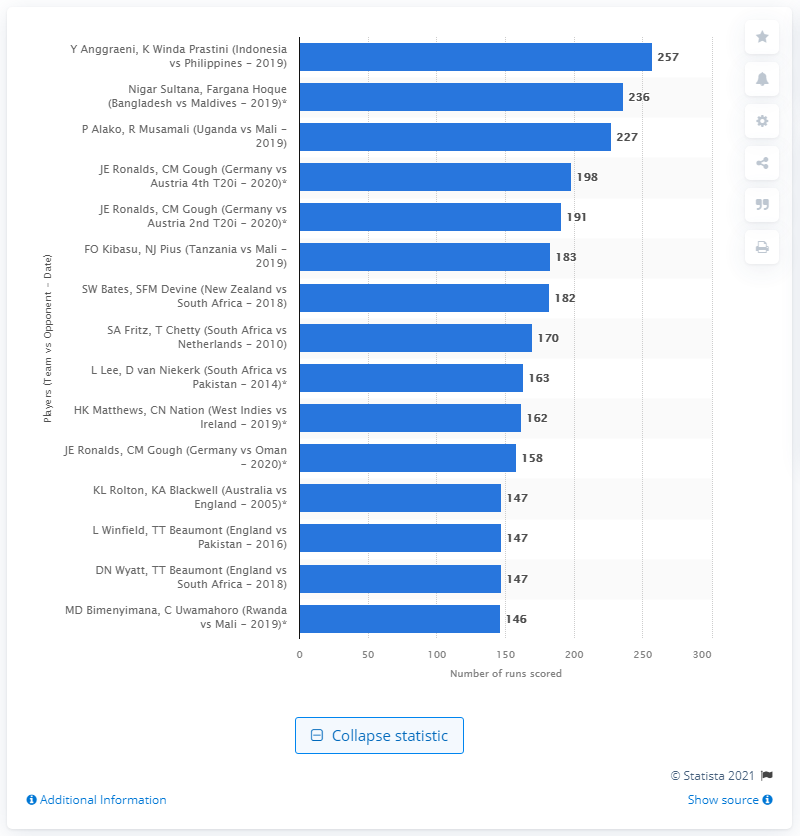

Question:
How many runs did Anggraeni and Prastini score against the Philippines in December 2019?

Expected:
257

Base model prediction:
257


In [17]:
example = test_raw[0]

display(example["image"])

print("Question:")
print(example["query"])

print("\nExpected:")
print(example["label"][0])

prediction = generate_answer(
    image=example["image"],
    question=example["query"],
    model=model,
    processor=processor,
)

print("\nBase model prediction:")
print(prediction)

## Answer normalization

In [18]:
def normalize_answer(text):
    text = str(text).strip().lower()

    # Remove common formatting noise.
    text = text.replace(",", "")
    text = text.replace("$", "")
    text = text.strip()

    # Remove surrounding quotation marks.
    text = text.strip("\"'")
    
    # Collapse whitespace.
    text = re.sub(r"\s+", " ", text)

    # Remove a final period.
    text = text.rstrip(".")

    return text

## Numeric parsing

In [19]:
def parse_number(text):
    """
    Returns a float if the complete answer looks numeric.
    Handles things such as:
        35
        35.7
        -12.4
        35%
        1,250
    """
    text = normalize_answer(text)

    is_percent = text.endswith("%")

    if is_percent:
        text = text[:-1].strip()

    try:
        value = float(text)
    except ValueError:
        return None

    return value

## ChartQA-style relaxed accuracy

In [20]:
def exact_match_score(prediction, reference):
    return int(
        normalize_answer(prediction)
        == normalize_answer(reference)
    )


def relaxed_match_score(
    prediction,
    reference,
    tolerance=0.05,
):
    """
    Exact match for text answers.

    For numeric answers, accept predictions within 5% of
    the reference value.
    """

    pred_norm = normalize_answer(prediction)
    ref_norm = normalize_answer(reference)

    # Exact match always wins.
    if pred_norm == ref_norm:
        return 1

    pred_num = parse_number(prediction)
    ref_num = parse_number(reference)

    # If both are numeric, apply relative tolerance.
    if pred_num is not None and ref_num is not None:

        if ref_num == 0:
            return int(abs(pred_num - ref_num) <= 1e-6)

        relative_error = abs(pred_num - ref_num) / abs(ref_num)

        return int(relative_error <= tolerance)

    return 0

## Define benchmark evaluation

In [21]:
def evaluate_model(
    model,
    processor,
    eval_dataset,
    description="Evaluating",
):
    rows = []

    model.eval()

    for i, sample in enumerate(
        tqdm(eval_dataset, desc=description)
    ):
        question = sample["query"]
        reference = str(sample["label"][0])

        prediction = generate_answer(
            image=sample["image"],
            question=question,
            model=model,
            processor=processor,
            max_new_tokens=32,
        )

        exact = exact_match_score(
            prediction,
            reference,
        )

        relaxed = relaxed_match_score(
            prediction,
            reference,
        )

        rows.append(
            {
                "index": i,
                "question": question,
                "reference": reference,
                "prediction": prediction,
                "exact_match": exact,
                "relaxed_accuracy": relaxed,
                "human_or_machine": sample["human_or_machine"],
            }
        )

    results = pd.DataFrame(rows)

    return results

## Run BASELINE evaluation

In [22]:
baseline_results = evaluate_model(
    model=model,
    processor=processor,
    eval_dataset=test_raw,
    description="Evaluating base Gemma 4 E2B",
)

Evaluating base Gemma 4 E2B:   0%|          | 0/200 [00:00<?, ?it/s]

## Baseline metrics

In [23]:
baseline_exact = baseline_results["exact_match"].mean()
baseline_relaxed = baseline_results["relaxed_accuracy"].mean()

print(f"Base exact match:      {baseline_exact:.4f}")
print(f"Base relaxed accuracy: {baseline_relaxed:.4f}")

Base exact match:      0.4750
Base relaxed accuracy: 0.6750


## Save baseline predictions

In [24]:
BASELINE_FILE = "/kaggle/working/chartqa_baseline_predictions.csv"

baseline_results.to_csv(
    BASELINE_FILE,
    index=False,
)

print(BASELINE_FILE)

/kaggle/working/chartqa_baseline_predictions.csv


## Inspect baseline errors

In [25]:
baseline_results[
    baseline_results["relaxed_accuracy"] == 0
][
    ["question", "reference", "prediction"]
].head(20)

,question,reference,prediction
1,What is the color of Ireland ?,brown,Orange
3,What is the difference between the highest and...,72,26%
5,How much points the blue line moved 2010 to 2019,10,30.1
7,How many places are mention in the graph?,5,4
8,What was the average growth in traffic in the ...,18.4,20.7
9,What is the difference between the percentage ...,27.5,22.5%
10,How many boys participated in high school spor...,20616,16690
16,What's the sum of responses that change the nu...,46,68%
17,What's the most popular option?,"Important, but lower priority",35% Top priority
23,Does the light blue bar have smallest value wh...,Yes,No


## Free cached GPU memory before training

In [26]:
gc.collect()
torch.cuda.empty_cache()

## Add LoRA adapters

In [27]:
model = FastVisionModel.get_peft_model(
    model,

    # Train both modalities.
    finetune_vision_layers=True,
    finetune_language_layers=True,

    # Train both attention and MLP components.
    finetune_attention_modules=True,
    finetune_mlp_modules=True,

    # LoRA parameters.
    r=32,
    lora_alpha=32,
    lora_dropout=0,
    bias="none",

    random_state=SEED,
    use_rslora=False,
    loftq_config=None,

    target_modules="all-linear",
)

[unsloth_zoo.log|WARNING]Unsloth: Failed to register input-embedding hook for `model.base_model.model.model.audio_tower`: `get_input_embeddings` not auto‑handled for Gemma4AudioModel; please override in the subclass.. Falling back to pre-forward hook.


## Show trainable parameters

In [28]:
model.print_trainable_parameters()

trainable params: 73,850,880 || all params: 5,197,028,896 || trainable%: 1.4210


## Create the trainer

In [29]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

In [30]:
trainer = SFTTrainer(
    model=model,

    train_dataset=converted_train_dataset,

    processing_class=processor.tokenizer,

    data_collator=UnslothVisionDataCollator(
        model,
        processor,
    ),

    args=SFTConfig(
        # ------------------------------------------------
        # Batch size
        # ------------------------------------------------
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,

        # ------------------------------------------------
        # Optimization
        # ------------------------------------------------
        learning_rate=2e-4,
        max_grad_norm=0.3,

        # One epoch for our first experiment.
        num_train_epochs=1,

        # The upstream notebook currently warns that
        # warmup_ratio is deprecated, so use steps instead.
        warmup_steps=100,

        optim="adamw_8bit",
        weight_decay=0.001,
        lr_scheduler_type="cosine",

        # ------------------------------------------------
        # Logging / checkpoints
        # ------------------------------------------------
        logging_steps=100,

        save_strategy="steps",
        save_steps=500,

        save_total_limit=2,

        # ------------------------------------------------
        # Reproducibility / output
        # ------------------------------------------------
        seed=SEED,
        output_dir=OUTPUT_DIR,
        report_to="none",

        # ------------------------------------------------
        # REQUIRED for Unsloth vision training
        # ------------------------------------------------
        remove_unused_columns=False,
        dataset_text_field="",

        dataset_kwargs={
            "skip_prepare_dataset": True,
        },

        max_length=1024,
    ),
)

Unsloth: Model does not have a default image size - using 512
Unsloth: Switching to float32 training since model cannot work with float16


## Check GPU memory immediately before training

In [31]:
gpu_stats = torch.cuda.get_device_properties(0)

start_gpu_memory = (
    torch.cuda.max_memory_reserved()
    / 1024**3
)

max_gpu_memory = (
    gpu_stats.total_memory
    / 1024**3
)

print(f"GPU: {gpu_stats.name}")
print(f"Total GPU memory: {max_gpu_memory:.2f} GB")
print(f"Currently reserved: {start_gpu_memory:.2f} GB")

GPU: Tesla T4
Total GPU memory: 14.56 GB
Currently reserved: 12.97 GB


## Train

In [32]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 8,000 | Num Epochs = 1 | Total steps = 2,000
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 73,850,880 of 5,197,028,896 (1.42% trained)
Unsloth: Not an error, but Gemma4ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
100,1.265832
200,0.403965
300,0.381045
400,0.362734
500,0.382392
600,0.367650
700,0.365264
800,0.356275
900,0.355832
1000,0.339197


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma4-e2b-chartqa/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma4-e2b-chartqa/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma4-e2b-chartqa/checkpoint-1500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma4-e2b-chartqa/checkpoint-2000/tokenizer_config.json.


In [33]:
print(trainer_stats)

TrainOutput(global_step=2000, training_loss=0.3920429048538208, metrics={'train_runtime': 11746.3203, 'train_samples_per_second': 0.681, 'train_steps_per_second': 0.17, 'total_flos': 3.981628079641766e+16, 'train_loss': 0.3920429048538208, 'epoch': 1.0})


In [34]:
final_gpu_memory = (
    torch.cuda.max_memory_reserved()
    / 1024**3
)

print(
    f"Peak reserved GPU memory: "
    f"{final_gpu_memory:.2f} GB"
)

Peak reserved GPU memory: 13.26 GB


## Save LoRA adapter immediately

In [35]:
model.save_pretrained(LORA_DIR)
processor.save_pretrained(LORA_DIR)

print(f"Saved LoRA adapter to:")
print(LORA_DIR)

Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma4-e2b-chartqa-lora/tokenizer_config.json.


Saved LoRA adapter to:
/kaggle/working/gemma4-e2b-chartqa-lora


## Clear cached memory

In [36]:
gc.collect()
torch.cuda.empty_cache()

## Test fine-tuned model on one example

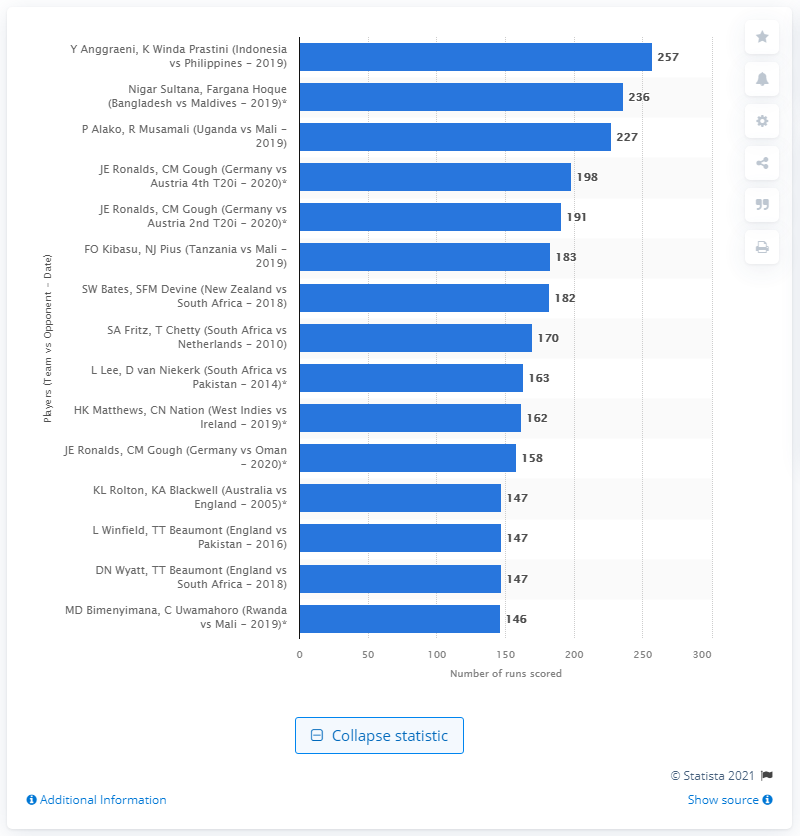

Question:
How many runs did Anggraeni and Prastini score against the Philippines in December 2019?

Expected:
257

Fine-tuned prediction:
257


In [37]:
example = test_raw[0]

display(example["image"])

print("Question:")
print(example["query"])

print("\nExpected:")
print(example["label"][0])

prediction = generate_answer(
    image=example["image"],
    question=example["query"],
    model=model,
    processor=processor,
)

print("\nFine-tuned prediction:")
print(prediction)

## Run POST-TRAINING evaluation

In [38]:
finetuned_results = evaluate_model(
    model=model,
    processor=processor,
    eval_dataset=test_raw,
    description="Evaluating fine-tuned Gemma 4 E2B",
)

Evaluating fine-tuned Gemma 4 E2B:   0%|          | 0/200 [00:00<?, ?it/s]

## Fine-tuned metrics

In [39]:
finetuned_exact = (
    finetuned_results["exact_match"].mean()
)

finetuned_relaxed = (
    finetuned_results["relaxed_accuracy"].mean()
)

print(f"Fine-tuned exact match:      {finetuned_exact:.4f}")
print(f"Fine-tuned relaxed accuracy: {finetuned_relaxed:.4f}")

Fine-tuned exact match:      0.6750
Fine-tuned relaxed accuracy: 0.7400


## Save fine-tuned predictions

In [40]:
FINETUNED_FILE = (
    "/kaggle/working/chartqa_finetuned_predictions.csv"
)

finetuned_results.to_csv(
    FINETUNED_FILE,
    index=False,
)

print(FINETUNED_FILE)

/kaggle/working/chartqa_finetuned_predictions.csv


## Create before/after comparison table

In [41]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Gemma 4 E2B Base",
            "Gemma 4 E2B + ChartQA LoRA",
        ],
        "Exact Match": [
            baseline_exact,
            finetuned_exact,
        ],
        "Relaxed Accuracy": [
            baseline_relaxed,
            finetuned_relaxed,
        ],
    }
)

comparison

,Model,Exact Match,Relaxed Accuracy
0,Gemma 4 E2B Base,0.475,0.675
1,Gemma 4 E2B + ChartQA LoRA,0.675,0.740


## Calculate improvement

In [42]:
exact_gain = (
    finetuned_exact
    - baseline_exact
)

relaxed_gain = (
    finetuned_relaxed
    - baseline_relaxed
)

print(
    f"Exact-match improvement: "
    f"{exact_gain:+.4f}"
)

print(
    f"Relaxed-accuracy improvement: "
    f"{relaxed_gain:+.4f}"
)

Exact-match improvement: +0.2000
Relaxed-accuracy improvement: +0.0650


## Plot the result

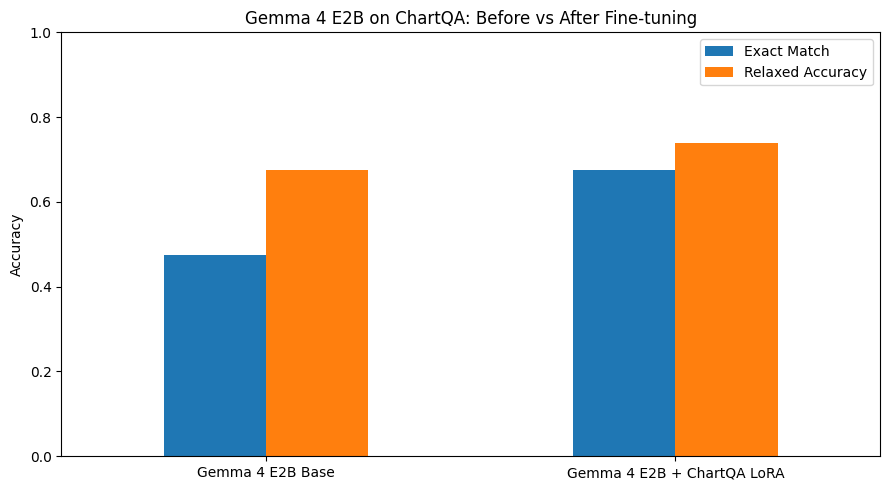

In [43]:
import matplotlib.pyplot as plt

ax = comparison.set_index("Model")[
    ["Exact Match", "Relaxed Accuracy"]
].plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Gemma 4 E2B on ChartQA: Before vs After Fine-tuning"
)

ax.set_ylabel("Accuracy")
ax.set_xlabel("")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Compare individual predictions

In [44]:
prediction_comparison = pd.DataFrame(
    {
        "question": baseline_results["question"],
        "reference": baseline_results["reference"],

        "base_prediction":
            baseline_results["prediction"],

        "base_score":
            baseline_results["relaxed_accuracy"],

        "finetuned_prediction":
            finetuned_results["prediction"],

        "finetuned_score":
            finetuned_results["relaxed_accuracy"],
    }
)

prediction_comparison.head(20)

,question,reference,base_prediction,base_score,finetuned_prediction,finetuned_score
0,How many runs did Anggraeni and Prastini score...,257,257,1,257,1
1,What is the color of Ireland ?,brown,Orange,0,Orange,0
2,What was the average national gross income per...,31780,31780,1,31780,1
3,What is the difference between the highest and...,72,26%,0,22,0
4,What percentage of families in Boston lived be...,11.7,11.7,1,10.5,0
5,How much points the blue line moved 2010 to 2019,10,30.1,0,29.2,0
6,What was the highest number of cannabis-relate...,18278,18278,1,18278,1
7,How many places are mention in the graph?,5,4,0,5,1
8,What was the average growth in traffic in the ...,18.4,20.7,0,18.4,1
9,What is the difference between the percentage ...,27.5,22.5%,0,37.5,0


## Cases fixed by fine-tuning

In [45]:
fixed_examples = prediction_comparison[
    (prediction_comparison["base_score"] == 0)
    &
    (prediction_comparison["finetuned_score"] == 1)
]

print(
    "Questions fixed by fine-tuning:",
    len(fixed_examples),
)

fixed_examples.head(20)

Questions fixed by fine-tuning: 27


,question,reference,base_prediction,base_score,finetuned_prediction,finetuned_score
7,How many places are mention in the graph?,5,4,0,5,1
8,What was the average growth in traffic in the ...,18.4,20.7,0,18.4,1
10,How many boys participated in high school spor...,20616,16690,0,20616,1
16,What's the sum of responses that change the nu...,46,68%,0,46,1
23,Does the light blue bar have smallest value wh...,Yes,No,0,Yes,1
24,What was the value of foodservice sales in U.S...,39.8,195.5,0,39.8,1
43,What is the difference between domestic market...,35,52,0,35,1
61,How many households did Belgium have in 2011?,4709852,4 709 852,0,4709852,1
69,Is the color of right-side bars lightest?,Yes,No,0,Yes,1
73,What's the add up value of Lithuania and Bolivia?,28.3,30.3,0,28.3,1


## Cases damaged by fine-tuning

In [46]:
regressed_examples = prediction_comparison[
    (prediction_comparison["base_score"] == 1)
    &
    (prediction_comparison["finetuned_score"] == 0)
]

print(
    "Questions that regressed:",
    len(regressed_examples),
)

regressed_examples.head(20)

Questions that regressed: 14


,question,reference,base_prediction,base_score,finetuned_prediction,finetuned_score
4,What percentage of families in Boston lived be...,11.7,11.7,1,10.5,0
51,What's the lefmost value of bar in China?,17,17,1,50,0
88,What was the GDP per capita in Malawi in 2019?,377.72,363.68,1,294.76,0
100,When was the peak for arrests recorded?,2006/07,2006/07,1,2015/16,0
113,What is x-axis represent in the chart?,Year,Year,1,Academic year,0
119,For how many years have the ratings on US and ...,1,1,1,2,0
120,Was the light blue dot higher than the dark bl...,No,No,1,Yes,0
128,"What is the sum total value of No,it could not ?",58,60%,1,27,0
132,What is the average Share of individuals who ...,56,53.33%,1,61,0
135,What was the production of rice in India in fi...,117.94,115,1,108.3,0


## Human vs machine-generated ChartQA performance

In [47]:
baseline_by_type = (
    baseline_results
    .groupby("human_or_machine")[
        ["exact_match", "relaxed_accuracy"]
    ]
    .mean()
)

finetuned_by_type = (
    finetuned_results
    .groupby("human_or_machine")[
        ["exact_match", "relaxed_accuracy"]
    ]
    .mean()
)

print("BASE MODEL")
display(baseline_by_type)

print("FINE-TUNED MODEL")
display(finetuned_by_type)

BASE MODEL


,exact_match,relaxed_accuracy
human_or_machine,,
0,0.336842,0.515789
1,0.600000,0.819048


FINE-TUNED MODEL


,exact_match,relaxed_accuracy
human_or_machine,,
0,0.526316,0.578947
1,0.809524,0.885714


In [48]:
TYPE_NAMES = {
    0: "Human",
    1: "Machine",
}

baseline_type_df = (
    baseline_results
    .assign(
        question_source=
            baseline_results["human_or_machine"].map(TYPE_NAMES)
    )
    .groupby("question_source")[
        ["exact_match", "relaxed_accuracy"]
    ]
    .mean()
)

finetuned_type_df = (
    finetuned_results
    .assign(
        question_source=
            finetuned_results["human_or_machine"].map(TYPE_NAMES)
    )
    .groupby("question_source")[
        ["exact_match", "relaxed_accuracy"]
    ]
    .mean()
)

display(baseline_type_df)
display(finetuned_type_df)

,exact_match,relaxed_accuracy
question_source,,
Human,0.336842,0.515789
Machine,0.600000,0.819048


,exact_match,relaxed_accuracy
question_source,,
Human,0.526316,0.578947
Machine,0.809524,0.885714


## Build human/machine comparison

In [49]:
source_comparison = pd.DataFrame(
    {
        "Base Human":
            baseline_type_df.loc[
                "Human",
                "relaxed_accuracy"
            ],

        "Fine-tuned Human":
            finetuned_type_df.loc[
                "Human",
                "relaxed_accuracy"
            ],

        "Base Machine":
            baseline_type_df.loc[
                "Machine",
                "relaxed_accuracy"
            ],

        "Fine-tuned Machine":
            finetuned_type_df.loc[
                "Machine",
                "relaxed_accuracy"
            ],
    },
    index=["Relaxed Accuracy"],
)

source_comparison

,Base Human,Fine-tuned Human,Base Machine,Fine-tuned Machine
Relaxed Accuracy,0.515789,0.578947,0.819048,0.885714


## Save complete comparison

In [50]:
COMPARISON_FILE = (
    "/kaggle/working/chartqa_prediction_comparison.csv"
)

prediction_comparison.to_csv(
    COMPARISON_FILE,
    index=False,
)

print(COMPARISON_FILE)

/kaggle/working/chartqa_prediction_comparison.csv


## Save experiment summary

In [51]:
experiment_summary = {
    "model": MODEL_NAME,

    "train_samples": len(train_raw),

    "test_samples": len(test_raw),

    "base_exact_match":
        float(baseline_exact),

    "base_relaxed_accuracy":
        float(baseline_relaxed),

    "finetuned_exact_match":
        float(finetuned_exact),

    "finetuned_relaxed_accuracy":
        float(finetuned_relaxed),

    "exact_match_gain":
        float(exact_gain),

    "relaxed_accuracy_gain":
        float(relaxed_gain),

    "seed": SEED,
}

SUMMARY_FILE = (
    "/kaggle/working/chartqa_experiment_summary.json"
)

with open(
    SUMMARY_FILE,
    "w",
) as f:
    json.dump(
        experiment_summary,
        f,
        indent=2,
    )

experiment_summary

{'model': 'unsloth/gemma-4-E2B-it',
 'train_samples': 8000,
 'test_samples': 200,
 'base_exact_match': 0.475,
 'base_relaxed_accuracy': 0.675,
 'finetuned_exact_match': 0.675,
 'finetuned_relaxed_accuracy': 0.74,
 'exact_match_gain': 0.20000000000000007,
 'relaxed_accuracy_gain': 0.06499999999999995,
 'seed': 3407}